# 03 – Isolation Forest

Baseline model using IsolationForest (n_estimators=200, contamination=0.038).

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from src.utils.preprocessing import generate_synthetic_dataset, preprocess_pipeline, FEATURE_COLUMNS
from src.models.isolation_forest import SatelliteIsolationForest

df = generate_synthetic_dataset(n_samples=120_000, seed=42)
feature_cols = [c for c in FEATURE_COLUMNS if c in df.columns]
train, val, test, scaler, all_feature_cols = preprocess_pipeline(df, feature_cols)

# Baseline Isolation Forest uses the core telemetry channels only.
X_train = train[feature_cols].values
X_test = test[feature_cols].values
y_test = test['label'].values

In [2]:
model = SatelliteIsolationForest(); model.fit(X_train)
metrics = model.evaluate(X_test, y_test)
for k, v in metrics.items(): print(f'  {k}: {v:.4f}')

  precision: 0.2727
  recall: 0.3078
  f1: 0.2892
  roc_auc: 0.7569


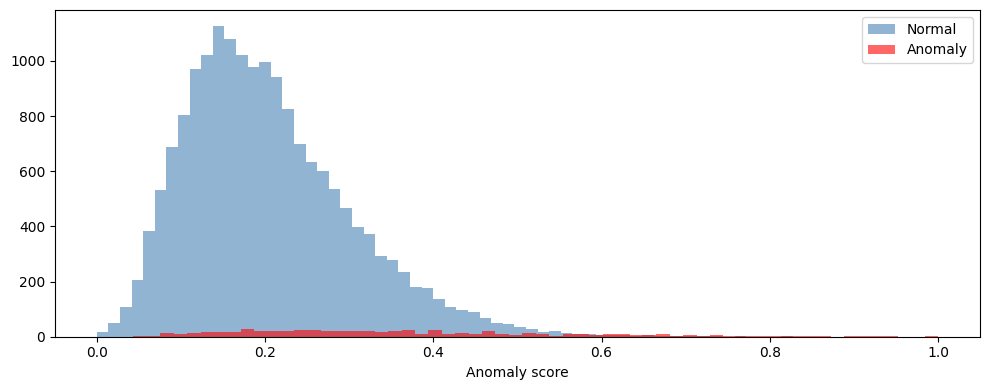

In [3]:
scores = model.anomaly_scores(X_test)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[y_test==0], bins=60, alpha=0.6, label='Normal', color='steelblue')
ax.hist(scores[y_test==1], bins=60, alpha=0.6, label='Anomaly', color='red')
ax.set_xlabel('Anomaly score'); ax.legend()
plt.tight_layout(); plt.savefig('../results/if_score_distribution.png', dpi=100); plt.show()

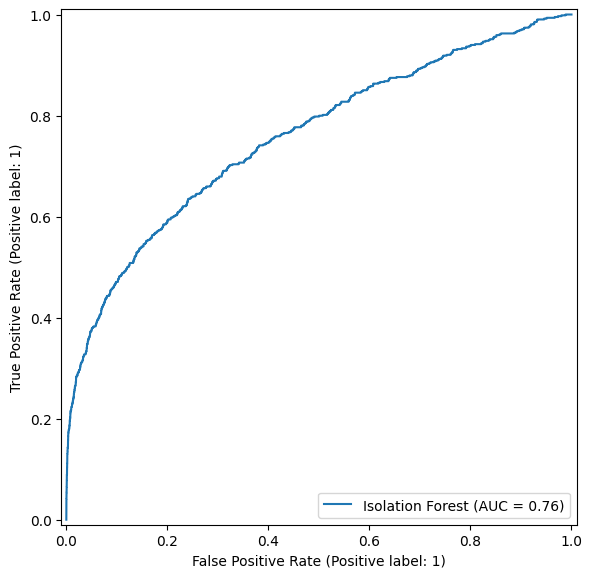

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, scores, ax=ax, name='Isolation Forest')
plt.tight_layout(); plt.savefig('../results/if_roc_curve.png', dpi=100); plt.show()